# Yisheng Zhang — UKAHT Agent Memory Ablation with Gemma

This Google Colab notebook runs a **real Gemma model locally inside Colab** using Hugging Face Transformers.  
No external OpenAI-compatible API endpoint is required.

## Research questions

1. Does short-term memory improve follow-up query resolution?
2. Does long-term memory improve cross-session contextual continuity?
3. Can irrelevant long-term memory introduce contextual noise?
4. Does relevance-gated memory reduce unnecessary carry-over?

## Conditions

- `no_memory`
- `short_term`
- `long_term_naive`
- `long_term_gated`
- `short_and_long_gated`

**Recommended runtime:** Colab GPU (T4 or better).


## 1. Install dependencies

Gemma can be run directly with Hugging Face Transformers. The notebook uses the instruction-tuned `google/gemma-3-1b-it` model to keep the Colab experiment relatively lightweight.


In [1]:
!pip -q install -U transformers accelerate huggingface_hub pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 32.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which 

## 2. Check GPU

In Colab, choose **Runtime → Change runtime type → GPU** before running the full experiment.


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: Running Gemma on CPU will be much slower.")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 3. Optional Hugging Face login

If Hugging Face asks for authentication or model-license acknowledgement:

1. Open the `google/gemma-3-1b-it` model page on Hugging Face.
2. Accept the model terms if prompted.
3. Create a Hugging Face access token.
4. In Colab, use the cell below to log in.

If the model downloads without authentication, you can skip this cell.


In [3]:
# Uncomment only if Hugging Face authentication is required.
#
# from huggingface_hub import notebook_login
# notebook_login()
from huggingface_hub import login
from getpass import getpass

token = getpass("Hugging Face Token: ")
login(token=token)

Hugging Face Token: ··········


## 4. Load Gemma directly in Colab

The model runs in the Colab runtime rather than through Ollama or an external API.


In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto"
)

model.eval()

print("Loaded:", MODEL_ID)
print("Model device:", next(model.parameters()).device)


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.00GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Loaded: google/gemma-3-1b-it
Model device: cuda:0


## 5. Gemma generation helper


In [5]:
def gemma_generate(system_instruction, user_prompt, max_new_tokens=48):
    messages = [
        {
            "role": "user",
            "content": (
                system_instruction.strip()
                + "\n\n"
                + user_prompt.strip()
            )
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_tensors="pt",
        return_dict=True
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    input_length = inputs["input_ids"].shape[-1]

    generated = output_ids[0][input_length:]

    return tokenizer.decode(
        generated,
        skip_special_tokens=True
    ).strip()


# Quick smoke test
test_answer = gemma_generate(
    "You are a concise archive assistant.",
    "Interpret this archive request: Show me photographs of Base A."
)

print(test_answer)

Okay, I understand. Please provide me with the location or details of “Base A” so I can locate the photographs.


## 6. UKAHT memory test set

The cases represent common archive interactions:

- multi-turn follow-up references;
- cross-session contextual continuity;
- irrelevant persistent memory that should not contaminate a new explicit request.


In [6]:
TEST_CASES = [
    {
        "case_id": "short_001",
        "experiment": "follow_up_resolution",
        "seed_memory": [],
        "turns": [
            {
                "query": "Show me photographs of Base A.",
                "expected_entities": ["Base A"],
                "forbidden_entities": []
            },
            {
                "query": "Which of these shows an interior?",
                "expected_entities": ["Base A", "interior"],
                "forbidden_entities": []
            },
            {
                "query": "Find another angle of the same site.",
                "expected_entities": ["Base A"],
                "forbidden_entities": []
            }
        ]
    },
    {
        "case_id": "short_002",
        "experiment": "follow_up_resolution",
        "seed_memory": [],
        "turns": [
            {
                "query": "Find images of Port Lockroy buildings.",
                "expected_entities": ["Port Lockroy", "buildings"],
                "forbidden_entities": []
            },
            {
                "query": "Now show me similar ones with snow around them.",
                "expected_entities": ["Port Lockroy", "buildings", "snow"],
                "forbidden_entities": []
            }
        ]
    },
    {
        "case_id": "long_001",
        "experiment": "relevant_long_term_memory",
        "seed_memory": [
            "The current archive exploration is focused on Port Lockroy buildings.",
            "The user previously selected historic station exterior photographs."
        ],
        "turns": [
            {
                "query": "Show me more relevant historical photographs.",
                "expected_entities": ["Port Lockroy", "buildings"],
                "forbidden_entities": []
            }
        ]
    },
    {
        "case_id": "long_002",
        "experiment": "relevant_long_term_memory",
        "seed_memory": [
            "The verified archive entity is Base A.",
            "Previous results contained interior workshop photographs from Base A."
        ],
        "turns": [
            {
                "query": "Find more from the same place.",
                "expected_entities": ["Base A"],
                "forbidden_entities": []
            }
        ]
    },
    {
        "case_id": "noise_001",
        "experiment": "irrelevant_memory_noise",
        "seed_memory": [
            "Earlier the user explored Base A building exteriors.",
            "Earlier the user viewed snowy station photographs."
        ],
        "turns": [
            {
                "query": "Find archive photographs of ships.",
                "expected_entities": ["ships"],
                "forbidden_entities": ["Base A"]
            }
        ]
    },
    {
        "case_id": "noise_002",
        "experiment": "irrelevant_memory_noise",
        "seed_memory": [
            "Previous session focused on Port Lockroy interiors."
        ],
        "turns": [
            {
                "query": "Show wildlife photographs from the archive.",
                "expected_entities": ["wildlife"],
                "forbidden_entities": ["Port Lockroy"]
            }
        ]
    }
]

print("Number of cases:", len(TEST_CASES))
print("Total dialogue turns:", sum(len(c["turns"]) for c in TEST_CASES))


Number of cases: 6
Total dialogue turns: 9


## 7. Memory storage and relevance gate


In [7]:
import re
from collections import deque

FOLLOW_UP_MARKERS = [
    "these",
    "same site",
    "same place",
    "similar ones",
    "another angle",
    "more relevant",
    "more from"
]

def token_set(text):
    return set(re.findall(r"[a-zA-Z]+", text.lower()))

def lexical_similarity(a, b):
    ta, tb = token_set(a), token_set(b)
    if not ta or not tb:
        return 0.0
    return len(ta & tb) / len(ta | tb)

def has_follow_up_marker(text):
    lower = text.lower()
    return any(marker in lower for marker in FOLLOW_UP_MARKERS)

class ShortTermMemory:
    def __init__(self, max_turns=4):
        self.turns = deque(maxlen=max_turns)

    def add(self, query, answer):
        self.turns.append({
            "query": query,
            "answer": answer
        })

    def render(self):
        if not self.turns:
            return ""
        lines = []
        for turn in self.turns:
            lines.append("User: " + turn["query"])
            lines.append("Assistant: " + turn["answer"])
        return "\n".join(lines)

class LongTermMemory:
    def __init__(self, memories=None):
        self.memories = list(memories or [])

    def render_all(self):
        return "\n".join("- " + m for m in self.memories)

    def render_relevant(self, query, threshold=0.08):
        selected = []
        for memory in self.memories:
            score = lexical_similarity(query, memory)
            if score >= threshold:
                selected.append((score, memory))

        selected.sort(reverse=True, key=lambda x: x[0])

        return "\n".join(
            f"- {memory}"
            for score, memory in selected
        )


## 8. Build prompts for each memory condition

The same Gemma model and decoding configuration are used in every condition.  
Only the memory context changes, making this an ablation study of the memory mechanism.


In [8]:
CONDITIONS = [
    "no_memory",
    "short_term",
    "long_term_naive",
    "long_term_gated",
    "short_and_long_gated"
]

SYSTEM_INSTRUCTION = '''
You are an archive-search assistant for the UK Antarctic Heritage Trust (UKAHT).

Your task is to interpret the user's archive query.
Use supplied memory only when it helps resolve the current request.
Resolve references such as "these", "same site", "same place", "similar ones",
or "another angle" from relevant context.

Do not let an old unrelated memory override an explicit new topic.
Do not invent historical facts.

Return one short sentence stating the resolved search intent.
Explicitly mention important archive entities and visual concepts when they
are needed to understand the search.
'''.strip()

def build_prompt(query, condition, short_memory, long_memory):
    sections = []

    if condition in {"short_term", "short_and_long_gated"}:
        short_text = short_memory.render()
        if short_text:
            sections.append(
                "RECENT CONVERSATION:\n" + short_text
            )

    if condition == "long_term_naive":
        long_text = long_memory.render_all()
        if long_text:
            sections.append(
                "PERSISTENT MEMORY:\n" + long_text
            )

    if condition in {"long_term_gated", "short_and_long_gated"}:
        if has_follow_up_marker(query):
            long_text = long_memory.render_all()
        else:
            long_text = long_memory.render_relevant(query)

        if long_text:
            sections.append(
                "RELEVANT PERSISTENT MEMORY:\n" + long_text
            )

    context = "\n\n".join(sections)

    if context:
        return (
            context
            + "\n\nCURRENT USER QUERY:\n"
            + query
        )

    return "CURRENT USER QUERY:\n" + query


## 9. Run Gemma memory ablation

This cell performs the full experiment. With `google/gemma-3-1b-it`, a Colab GPU should complete the small test set in a reasonable time.


In [9]:
import time
import pandas as pd

records = []

total_generations = len(CONDITIONS) * sum(
    len(case["turns"]) for case in TEST_CASES
)

generation_index = 0

for condition in CONDITIONS:
    print("\n=== CONDITION:", condition, "===")

    for case in TEST_CASES:
        short_memory = ShortTermMemory(max_turns=4)
        long_memory = LongTermMemory(case["seed_memory"])

        for turn_index, turn in enumerate(case["turns"], start=1):
            generation_index += 1

            prompt = build_prompt(
                query=turn["query"],
                condition=condition,
                short_memory=short_memory,
                long_memory=long_memory
            )

            started = time.perf_counter()

            answer = gemma_generate(
                SYSTEM_INSTRUCTION,
                prompt,
                max_new_tokens=48
            )

            latency = time.perf_counter() - started

            records.append({
                "case_id": case["case_id"],
                "experiment": case["experiment"],
                "condition": condition,
                "turn_index": turn_index,
                "query": turn["query"],
                "expected_entities": turn["expected_entities"],
                "forbidden_entities": turn["forbidden_entities"],
                "answer": answer,
                "latency_seconds": round(latency, 4)
            })

            short_memory.add(
                query=turn["query"],
                answer=answer
            )

            print(
                f"[{generation_index}/{total_generations}] "
                f"{case['case_id']} turn {turn_index} "
                f"({latency:.2f}s)"
            )

results_df = pd.DataFrame(records)

print("\nExperiment complete.")
print("Records:", len(results_df))
results_df.head(10)



=== CONDITION: no_memory ===
[1/45] short_001 turn 1 (1.54s)
[2/45] short_001 turn 2 (0.78s)
[3/45] short_001 turn 3 (1.05s)
[4/45] short_002 turn 1 (1.12s)
[5/45] short_002 turn 2 (0.83s)
[6/45] long_001 turn 1 (3.49s)
[7/45] long_002 turn 1 (1.52s)
[8/45] noise_001 turn 1 (0.64s)
[9/45] noise_002 turn 1 (1.59s)

=== CONDITION: short_term ===
[10/45] short_001 turn 1 (1.52s)
[11/45] short_001 turn 2 (0.77s)
[12/45] short_001 turn 3 (1.05s)
[13/45] short_002 turn 1 (1.11s)
[14/45] short_002 turn 2 (1.48s)
[15/45] long_001 turn 1 (3.39s)
[16/45] long_002 turn 1 (1.50s)
[17/45] noise_001 turn 1 (0.65s)
[18/45] noise_002 turn 1 (1.56s)

=== CONDITION: long_term_naive ===
[19/45] short_001 turn 1 (1.53s)
[20/45] short_001 turn 2 (0.79s)
[21/45] short_001 turn 3 (1.06s)
[22/45] short_002 turn 1 (1.15s)
[23/45] short_002 turn 2 (0.84s)
[24/45] long_001 turn 1 (1.12s)
[25/45] long_002 turn 1 (1.41s)
[26/45] noise_001 turn 1 (1.11s)
[27/45] noise_002 turn 1 (0.90s)

=== CONDITION: long_term_g

,case_id,experiment,condition,turn_index,query,expected_entities,forbidden_entities,answer,latency_seconds
0,short_001,follow_up_resolution,no_memory,1,Show me photographs of Base A.,[Base A],[],"I can search for photographs of Base A, but I ...",1.5357
1,short_001,follow_up_resolution,no_memory,2,Which of these shows an interior?,"[Base A, interior]",[],The provided archive does not contain any imag...,0.7779
2,short_001,follow_up_resolution,no_memory,3,Find another angle of the same site.,[Base A],[],I need more information about the specific sit...,1.0533
3,short_002,follow_up_resolution,no_memory,1,Find images of Port Lockroy buildings.,"[Port Lockroy, buildings]",[],I will search for images of Port Lockroy build...,1.1184
4,short_002,follow_up_resolution,no_memory,2,Now show me similar ones with snow around them.,"[Port Lockroy, buildings, snow]",[],I need to find references to Antarctic landsca...,0.8297
5,long_001,relevant_long_term_memory,no_memory,1,Show me more relevant historical photographs.,"[Port Lockroy, buildings]",[],"I can help you with that, but I need to know w...",3.4871
6,long_002,relevant_long_term_memory,no_memory,1,Find more from the same place.,[Base A],[],I need to find more information about the same...,1.5158
7,noise_001,irrelevant_memory_noise,no_memory,1,Find archive photographs of ships.,[ships],[Base A],I can help you find archive photographs of ships.,0.6440
8,noise_002,irrelevant_memory_noise,no_memory,1,Show wildlife photographs from the archive.,[wildlife],[Port Lockroy],I can search the archive for photographs of wi...,1.5940
9,short_001,follow_up_resolution,short_term,1,Show me photographs of Base A.,[Base A],[],"I can search for photographs of Base A, but I ...",1.5162


## 10. Automatic evaluation

The experiment uses simple entity-presence checks:

- **Context Resolution Accuracy**: expected archive entities appear in Gemma's resolved intent.
- **Irrelevant Memory Leak Rate**: a known irrelevant entity is incorrectly carried into the answer.
- **Overall Success Rate**: expected entities are present and forbidden entities are absent.

These metrics are intentionally transparent and reproducible for the small controlled test set.


In [10]:
def contains_all(text, terms):
    lower = text.lower()
    return all(term.lower() in lower for term in terms)

def contains_any(text, terms):
    lower = text.lower()
    return any(term.lower() in lower for term in terms)

def evaluate_record(row):
    expected_ok = (
        contains_all(row["answer"], row["expected_entities"])
        if row["expected_entities"]
        else True
    )

    memory_leak = (
        contains_any(row["answer"], row["forbidden_entities"])
        if row["forbidden_entities"]
        else False
    )

    return pd.Series({
        "context_resolution_success": int(expected_ok),
        "irrelevant_memory_leak": int(memory_leak),
        "overall_success": int(expected_ok and not memory_leak)
    })

metric_df = results_df.apply(evaluate_record, axis=1)
scored_df = pd.concat([results_df, metric_df], axis=1)

summary_df = (
    scored_df
    .groupby("condition", as_index=False)
    .agg(
        n_turns=("overall_success", "size"),
        context_resolution_accuracy=("context_resolution_success", "mean"),
        irrelevant_memory_leak_rate=("irrelevant_memory_leak", "mean"),
        overall_success_rate=("overall_success", "mean"),
        avg_latency_seconds=("latency_seconds", "mean")
    )
)

summary_df


,condition,n_turns,context_resolution_accuracy,irrelevant_memory_leak_rate,overall_success_rate,avg_latency_seconds
0,long_term_gated,9,0.666667,0.000000,0.666667,1.681967
1,long_term_naive,9,0.666667,0.111111,0.555556,1.100967
2,no_memory,9,0.444444,0.000000,0.444444,1.395100
3,short_and_long_gated,9,0.777778,0.000000,0.777778,1.441456
4,short_term,9,0.555556,0.000000,0.555556,1.447689


## 11. Results by experiment type


In [11]:
experiment_summary_df = (
    scored_df
    .groupby(
        ["condition", "experiment"],
        as_index=False
    )
    .agg(
        context_resolution_accuracy=("context_resolution_success", "mean"),
        irrelevant_memory_leak_rate=("irrelevant_memory_leak", "mean"),
        overall_success_rate=("overall_success", "mean"),
        avg_latency_seconds=("latency_seconds", "mean")
    )
)

experiment_summary_df


,condition,experiment,context_resolution_accuracy,irrelevant_memory_leak_rate,overall_success_rate,avg_latency_seconds
0,long_term_gated,follow_up_resolution,0.4,0.0,0.4,1.06820
1,long_term_gated,irrelevant_memory_noise,1.0,0.0,1.0,3.92380
2,long_term_gated,relevant_long_term_memory,1.0,0.0,1.0,0.97455
3,long_term_naive,follow_up_resolution,0.4,0.0,0.4,1.07406
4,long_term_naive,irrelevant_memory_noise,1.0,0.5,0.5,1.00585
5,long_term_naive,relevant_long_term_memory,1.0,0.0,1.0,1.26335
6,no_memory,follow_up_resolution,0.4,0.0,0.4,1.06300
7,no_memory,irrelevant_memory_noise,1.0,0.0,1.0,1.11900
8,no_memory,relevant_long_term_memory,0.0,0.0,0.0,2.50145
9,short_and_long_gated,follow_up_resolution,0.6,0.0,0.6,1.71554


## 12. Visualise the ablation


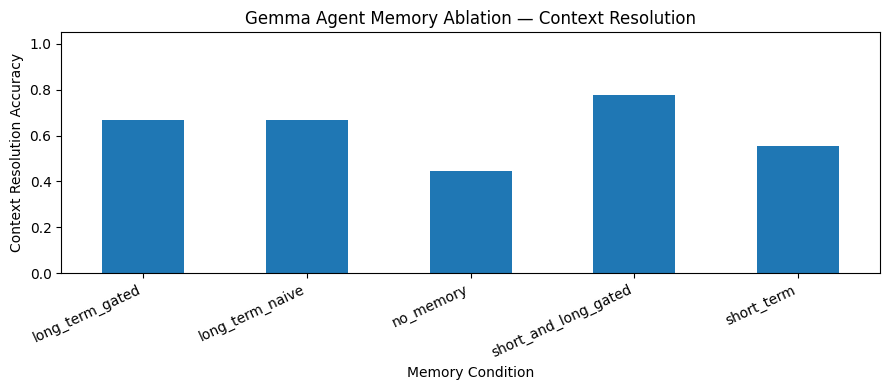

In [12]:
import matplotlib.pyplot as plt

ax = summary_df.plot(
    x="condition",
    y="context_resolution_accuracy",
    kind="bar",
    legend=False,
    figsize=(9, 4)
)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Context Resolution Accuracy")
ax.set_xlabel("Memory Condition")
ax.set_title("Gemma Agent Memory Ablation — Context Resolution")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


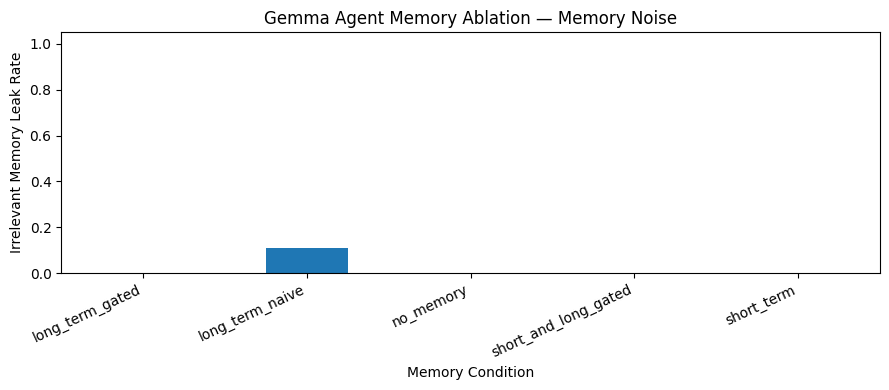

In [13]:
ax = summary_df.plot(
    x="condition",
    y="irrelevant_memory_leak_rate",
    kind="bar",
    legend=False,
    figsize=(9, 4)
)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Irrelevant Memory Leak Rate")
ax.set_xlabel("Memory Condition")
ax.set_title("Gemma Agent Memory Ablation — Memory Noise")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


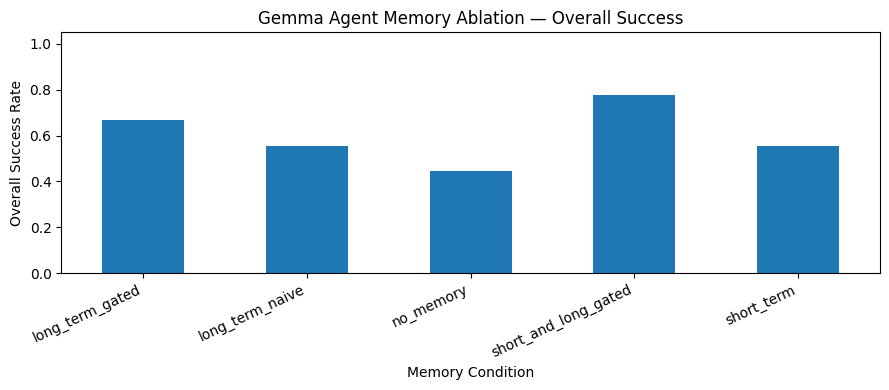

In [14]:
ax = summary_df.plot(
    x="condition",
    y="overall_success_rate",
    kind="bar",
    legend=False,
    figsize=(9, 4)
)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Overall Success Rate")
ax.set_xlabel("Memory Condition")
ax.set_title("Gemma Agent Memory Ablation — Overall Success")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 13. Error analysis


In [15]:
error_cases = scored_df[
    (scored_df["context_resolution_success"] == 0)
    | (scored_df["irrelevant_memory_leak"] == 1)
][[
    "case_id",
    "experiment",
    "condition",
    "turn_index",
    "query",
    "expected_entities",
    "forbidden_entities",
    "answer",
    "context_resolution_success",
    "irrelevant_memory_leak"
]]

error_cases


,case_id,experiment,condition,turn_index,query,expected_entities,forbidden_entities,answer,context_resolution_success,irrelevant_memory_leak
1,short_001,follow_up_resolution,no_memory,2,Which of these shows an interior?,"[Base A, interior]",[],The provided archive does not contain any imag...,0,0
2,short_001,follow_up_resolution,no_memory,3,Find another angle of the same site.,[Base A],[],I need more information about the specific sit...,0,0
4,short_002,follow_up_resolution,no_memory,2,Now show me similar ones with snow around them.,"[Port Lockroy, buildings, snow]",[],I need to find references to Antarctic landsca...,0,0
5,long_001,relevant_long_term_memory,no_memory,1,Show me more relevant historical photographs.,"[Port Lockroy, buildings]",[],"I can help you with that, but I need to know w...",0,0
6,long_002,relevant_long_term_memory,no_memory,1,Find more from the same place.,[Base A],[],I need to find more information about the same...,0,0
10,short_001,follow_up_resolution,short_term,2,Which of these shows an interior?,"[Base A, interior]",[],I need to see images of the interior of the base.,0,0
11,short_001,follow_up_resolution,short_term,3,Find another angle of the same site.,[Base A],[],I need to examine a different visual represent...,0,0
14,long_001,relevant_long_term_memory,short_term,1,Show me more relevant historical photographs.,"[Port Lockroy, buildings]",[],"I can help you with that, but I need to know w...",0,0
15,long_002,relevant_long_term_memory,short_term,1,Find more from the same place.,[Base A],[],I need to find more information about the same...,0,0
19,short_001,follow_up_resolution,long_term_naive,2,Which of these shows an interior?,"[Base A, interior]",[],The provided archive does not contain any imag...,0,0


## 14. Export experiment artifacts


In [16]:
summary_df.to_csv(
    "gemma_memory_ablation_summary.csv",
    index=False
)

experiment_summary_df.to_csv(
    "gemma_memory_ablation_by_experiment.csv",
    index=False
)

scored_df.to_json(
    "gemma_memory_ablation_item_results.json",
    orient="records",
    indent=2,
    force_ascii=False
)

print("Saved:")
print("- gemma_memory_ablation_summary.csv")
print("- gemma_memory_ablation_by_experiment.csv")
print("- gemma_memory_ablation_item_results.json")


Saved:
- gemma_memory_ablation_summary.csv
- gemma_memory_ablation_by_experiment.csv
- gemma_memory_ablation_item_results.json


## 15. Interpretation guidance

The main comparison is not simply whether "memory is better".

A stronger analysis asks:

- Does short-term memory specifically help ambiguous follow-up turns?
- Does persistent memory help when the user refers back to a previous session?
- Does naive long-term memory contaminate unrelated explicit queries?
- Does relevance gating preserve useful memory while reducing noise?
- What latency cost is introduced by longer prompts?

This gives the experiment a clear ablation structure and makes it suitable for later integration with the production UKAHT agent.


## 16. Suggested experiment-log statement

> We evaluated Gemma-based archive interaction under five memory configurations: no memory, short-term memory, naive long-term memory, relevance-gated long-term memory, and combined gated memory. The same Gemma model and decoding settings were maintained across all conditions so that the experiment isolated the contribution of memory context. Evaluation focused on follow-up query resolution, cross-session continuity, irrelevant-memory leakage, overall task success, and inference latency.
